In [1]:
%load_ext autoreload 
%autoreload 2
from xtr_estimator.logger import setup_logger

logger = setup_logger()

show_ignored_voxels=True set_ylim=False is_composite=False std_cutoff=3.0 solvent_density=0.4 minimum_datapoints=10 show_plot=True save_to_file=True markersize=1
1
(<class 'float'>, 2.299999952316284, <class 'float'>, 2.3)
show_ignored_voxels=True set_ylim=(0, 1.5) is_composite=False std_cutoff=3.0 solvent_density=0.4 minimum_datapoints=10 show_plot=True save_to_file=True markersize=1


(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Difference Map $-\\Delta \\rho$ (standard deviations)', ylabel='Extrapolation factor $ \\chi^{-1} = -\\Delta\\rho/\\rho_{0}$'>,
 (np.float64(0.672186244617809), np.float64(0.1310570955200573)))

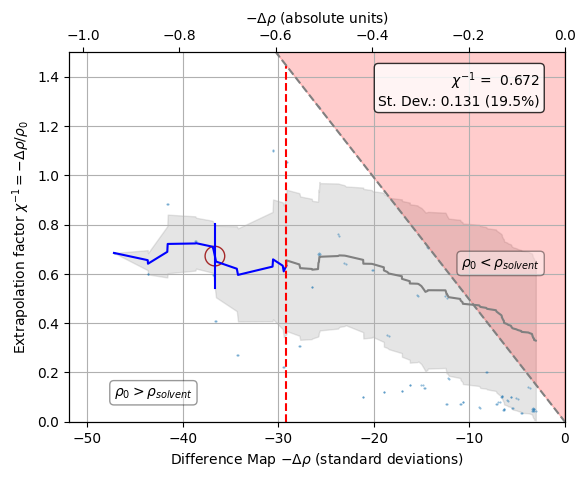

In [ ]:
import copy 

from xtr_estimator.configuration import Settings, MaskingSettings
from xtr_estimator.processing import get_maps, prepare_maps
from xtr_estimator.masking import make_inclusion_mask
from xtr_estimator.estimation import plot_extrapolation_estimate
from dataset_configs import apply_config_myoglobin_general

config = apply_config_myoglobin_general("0.1ps")
config["map_processing"]["calculate_diffmap_before_f000"] = True

print(config.plot)
print(config.plot.markersize)
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(
    f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}"
)
config_nse=copy.deepcopy(config)
config_nse.masking.simple()

inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)


config["plot"]["set_ylim"] = ((0, 1.5))
print(config.plot)
plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)

2026-04-17 17:15:19 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-04-17 17:15:19 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-04-17 17:15:19 [info     ] Computing difference map.     
2026-04-17 17:15:21 [info     ]   using negentropy max.        kparameter=0.0
2026-04-17 17:15:21 [info     ] Searching for max-negentropy TV denoising weight method='golden-section search'
2026-04-17 17:15:21 [info     ] This may take some time...    
2026-04-17 17:15:22 [info     ] Optimal TV weight found        final_negentropy=3.73e-01 initial_negentropy=3.61e-04 weight=4.80e-02
2026-04-17 17:15:24 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-04-17 17:15:24 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-04-17 17:15:24 [info     ] Computing difference map.     
2026-04-17 17:15:26 [info     ]   using negentropy max.        kparameter=0.02
2026-04-17 17:15:26 [

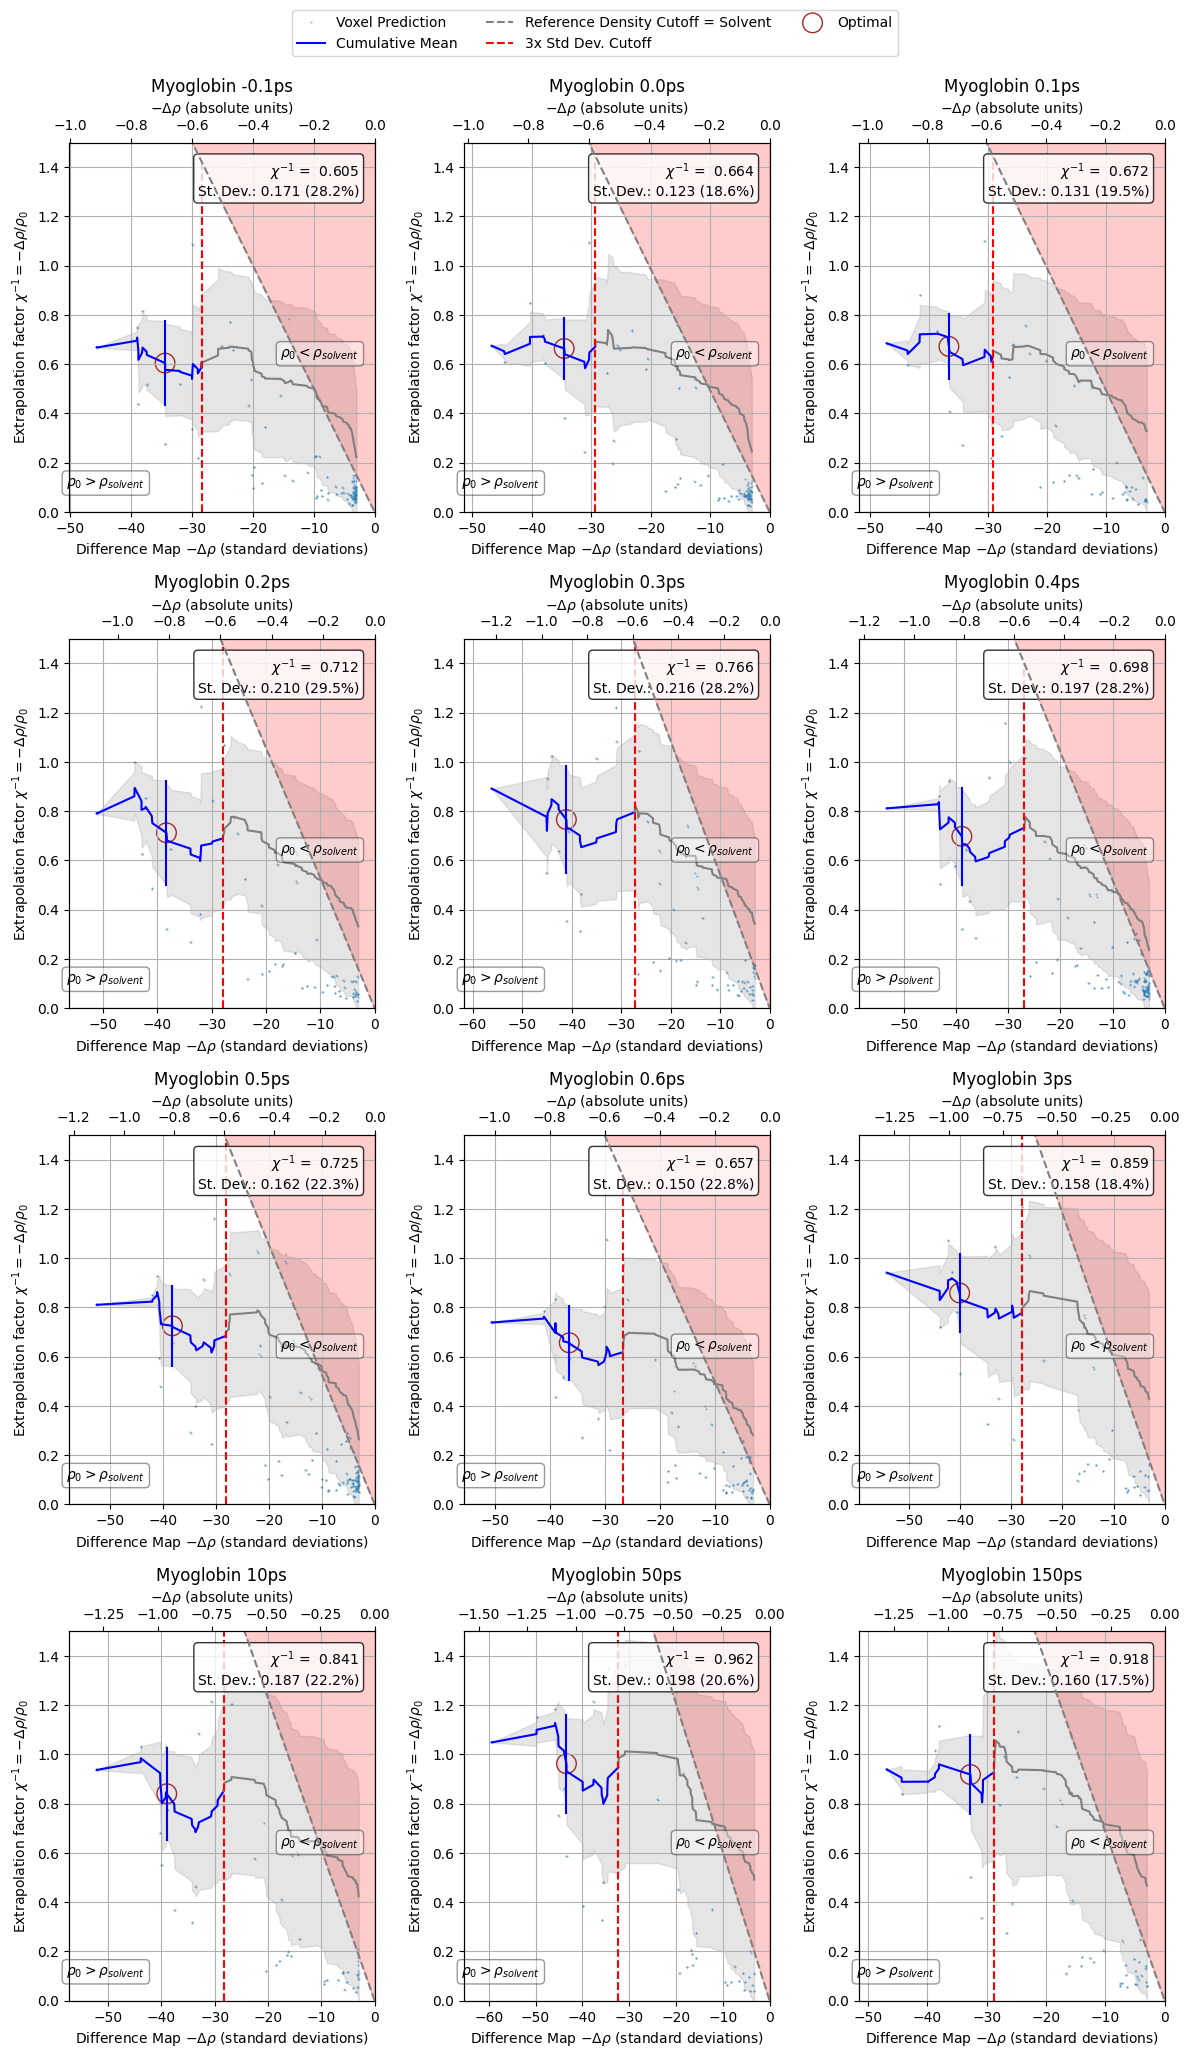

In [9]:
# from masking import make_inclusion_mask
# from estimation import plot_extrapolation_estimate_new
# from logger import setup_logger
import logging 
import matplotlib.pyplot as plt
logger = setup_logger(log_level=logging.ERROR)

# 1. Create the main figure
fig,axs = plt.subplots(4,3, figsize=(12, 20), tight_layout=True)

for i, ax in enumerate(axs.flatten()):
    # if not i: continue

    config = apply_config_myoglobin_general(i)
    ax.set_title(config["general"]["name_human"])
    config["masking"]["dark_size_threshold"] = 0

    unscaled_dark, unscaled_triggered = get_maps(config)
    # config["map_processing"]["diffmap_type"]="vanilla"
    config["map_processing"]["calculate_diffmap_before_f000"] = True
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)


    config_nse.masking.simple()
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)
    if config["map_processing"]["diffmap_type"]=="tv":
        config["plot"]["set_ylim"] = ((0, 1.5))
    else:
        config["plot"]["set_ylim"] = ((0, 0.6))

    plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config, ax)


handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, 
    loc='upper center', 
    ncol=3,             # Adjust ncol to spread them horizontally
    bbox_to_anchor=(0.5, 1.03)) # Moves it above the subplots

# 3. Use tight_layout but leave room at the top for the legend
plt.tight_layout()


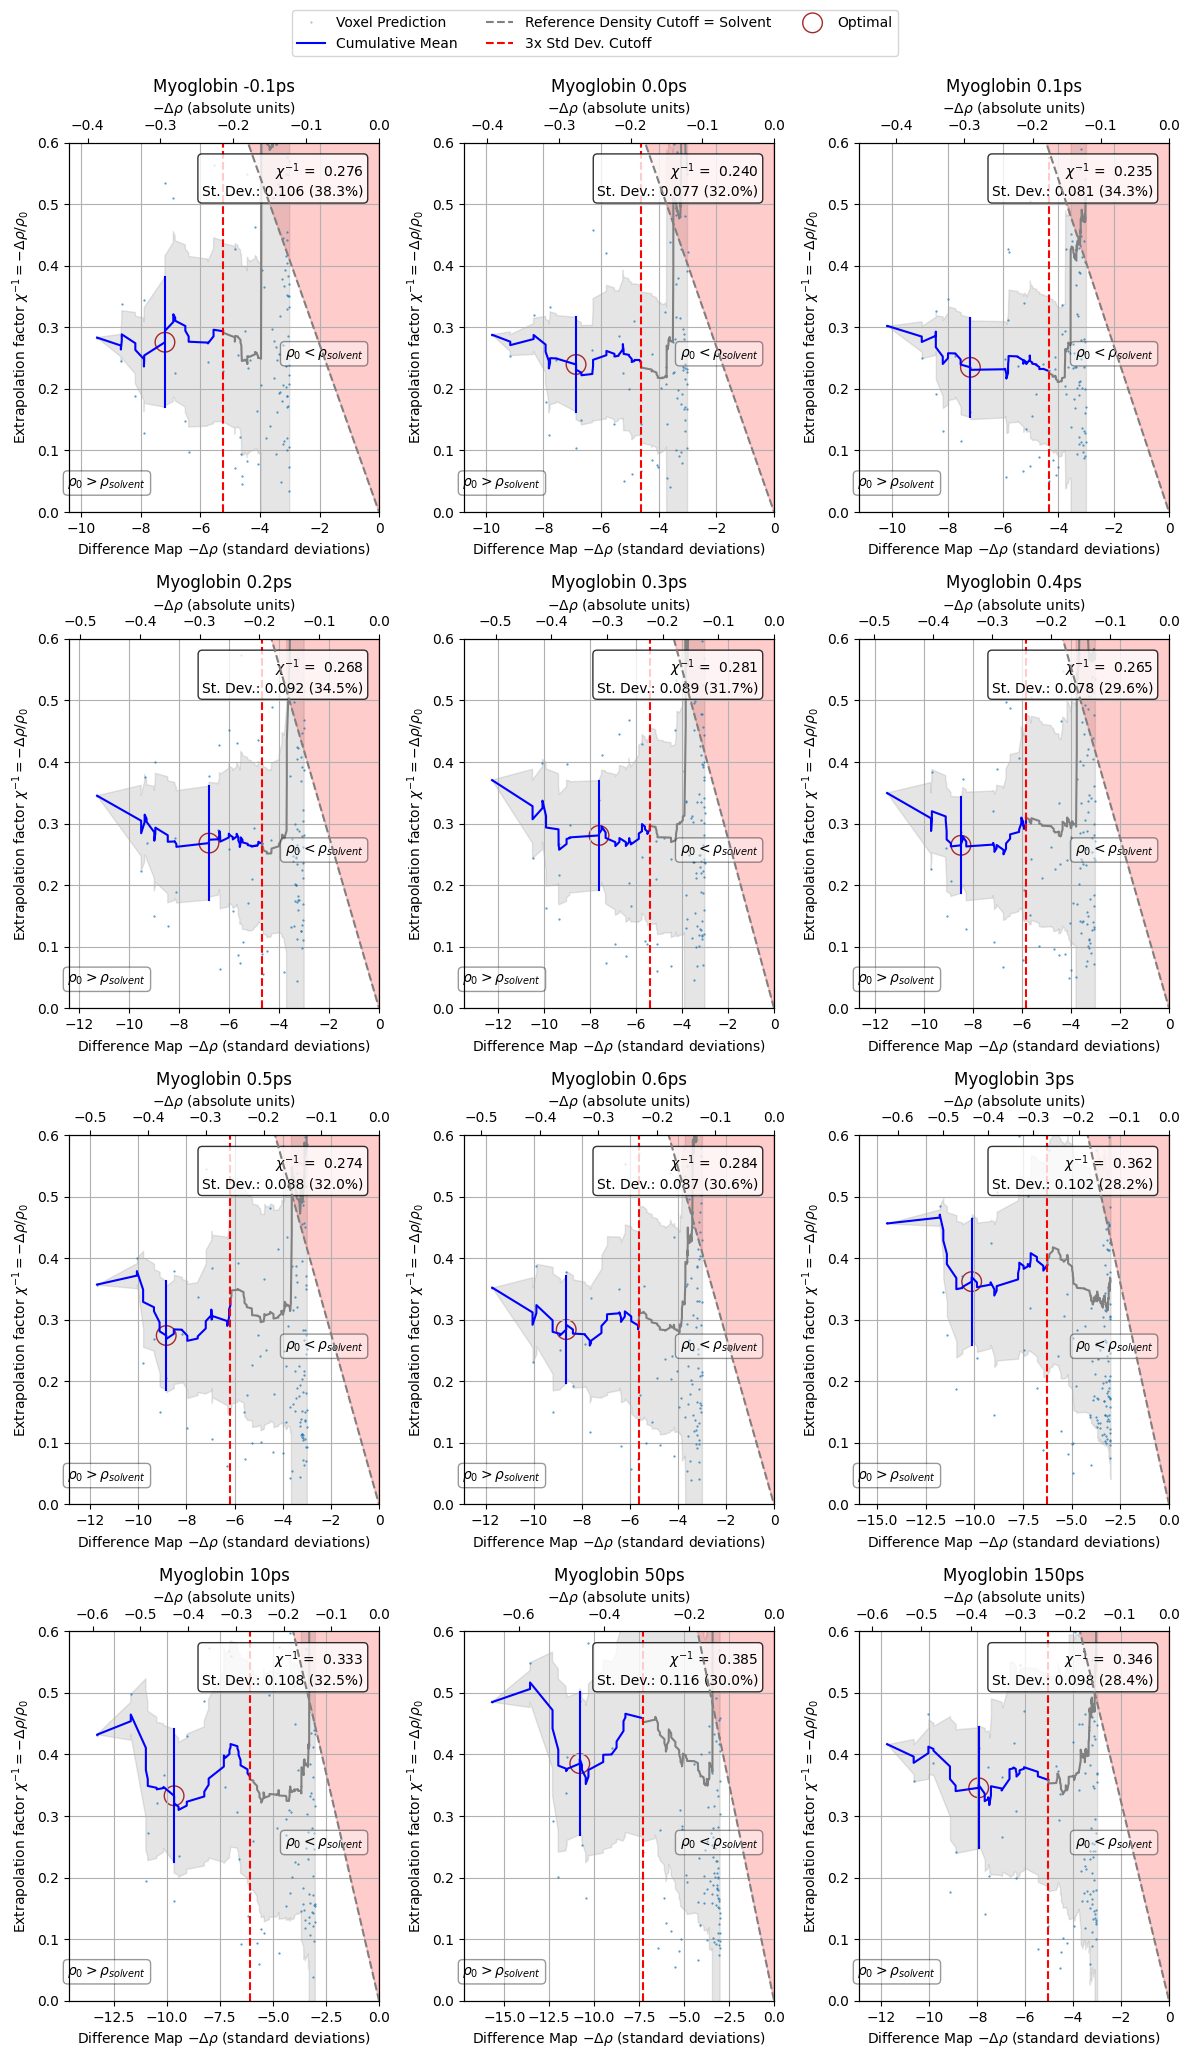

In [ ]:
# from masking import make_inclusion_mask
# from estimation import plot_extrapolation_estimate_new
# from logger import setup_logger
import logging 
import matplotlib.pyplot as plt
logger = setup_logger(log_level=logging.ERROR)

# 1. Create the main figure
fig,axs = plt.subplots(4,3, figsize=(12, 20), tight_layout=True)

for i, ax in enumerate(axs.flatten()):
    # if not i: continue

    config = apply_config_myoglobin_general(i)
    ax.set_title(config["general"]["name_human"])
    config["masking"]["dark_size_threshold"] = 0

    unscaled_dark, unscaled_triggered = get_maps(config)
    config["map_processing"]["diffmap_type"]="vanilla"
    config["map_processing"]["calculate_diffmap_before_f000"] = False
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)


    config_nse.masking.simple()
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)
    if config["map_processing"]["diffmap_type"]=="tv":
        config["plot"]["set_ylim"] = ((0, 1.5))
    else:
        config["plot"]["set_ylim"] = ((0, 0.6))

    plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config, ax)


handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, 
    loc='upper center', 
    ncol=3,             # Adjust ncol to spread them horizontally
    bbox_to_anchor=(0.5, 1.03)) # Moves it above the subplots

# 3. Use tight_layout but leave room at the top for the legend
plt.tight_layout()

